# Обучение моделей рекомендательной системы


В этом notebook мы обучим две основные модели для рекомендательной системы:
1. **Content-based модель** - рекомендации на основе схожести контента
2. **Collaborative filtering модель** - рекомендации на основе поведения пользователей (с использованием NMF)

## Импорт библиотек

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import NMF

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

DATA_DIR = "data/ml-1m"
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

## Загрузка данных

In [2]:
ratings = pd.read_csv(f"{DATA_DIR}/ratings.dat", sep="::", names=["userId","movieId","rating","timestamp"], engine="python", encoding="latin1")
movies = pd.read_csv(f"{DATA_DIR}/movies.dat", sep="::", names=["movieId","title","genres"], engine="python", encoding="latin1")
users = pd.read_csv(f"{DATA_DIR}/users.dat", sep="::", names=["userId","gender","age","occupation","zip"], engine="python", encoding="latin1")

## Анализ данных

In [3]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291



- userId: идентификатор пользователя
- movieId: идентификатор фильма
- rating: рейтинг фильма пользователем
- timestamp: время, когда пользователь выставил рейтинг

In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy



- movieId: идентификатор фильма
- title: название фильма
- genres: жанры фильма перечисленные через |

In [5]:
users.head()

,userId,gender,age,occupation,zip
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455



- userId: идентификатор пользователя
- gender: пол пользователя
- age: возраст пользователя
- occupation: профессия пользователя (нам не нужно)
- zip: почтовый индекс пользователя

In [6]:
print(f"- Пользователей: {len(users)}")
print(f"- Фильмов: {len(movies)}")
print(f"- Рейтингов: {len(ratings)}")

- Пользователей: 6040
- Фильмов: 3883
- Рейтингов: 1000209


In [ ]:
with pd.option_context('display.float_format', '{:.0f}'.format): # округление чтобы только одно число после запятой было
    display(ratings.describe())


,userId,movieId,rating,timestamp
count,1000209,1000209,1000209,1000209
mean,3025,1866,4,972243695
std,1728,1096,1,12152559
min,1,1,1,956703932
25%,1506,1030,3,965302637
50%,3070,1835,4,973018006
75%,4476,2770,4,975220939
max,6040,3952,5,1046454590


In [8]:
with pd.option_context('display.float_format', '{:.0f}'.format):
    display(users.describe())

,userId,age,occupation
count,6040,6040,6040
mean,3020,31,8
std,1744,13,6
min,1,1,0
25%,1511,25,3
50%,3020,25,7
75%,4530,35,14
max,6040,56,20


In [9]:
print('Пропуски в рейтингах:')
ratings.isna().sum()

Пропуски в рейтингах:


userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [10]:
print('Пропуски в фильмах:')
movies.isna().sum()

Пропуски в фильмах:


movieId    0
title      0
genres     0
dtype: int64

In [11]:
print('Пропуски в пользователях:')
users.isna().sum()

Пропуски в пользователях:


userId        0
gender        0
age           0
occupation    0
zip           0
dtype: int64

## Визуализация данных

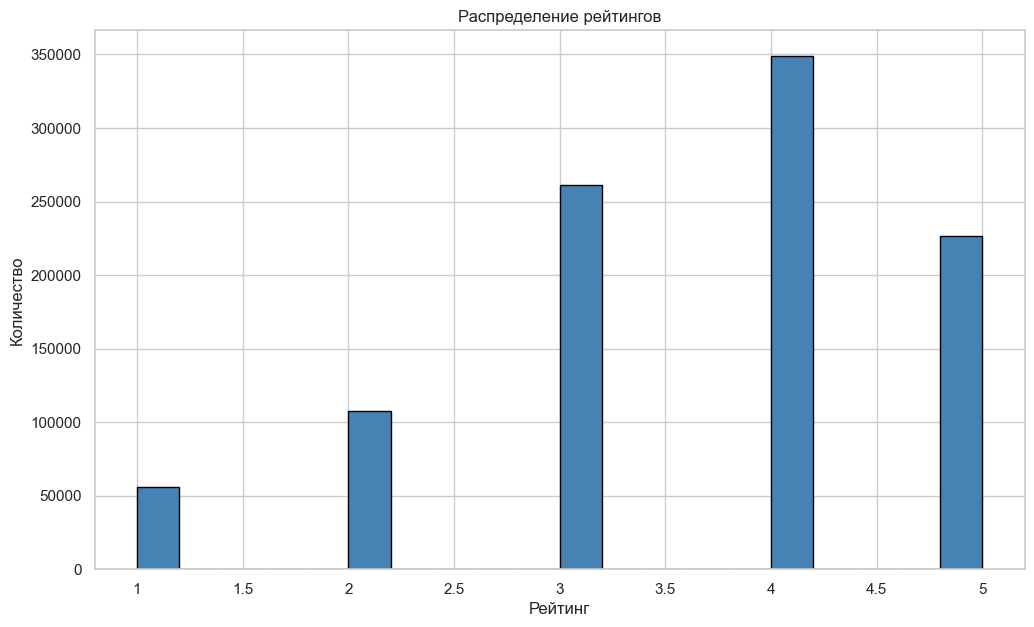

In [12]:
plt.figure()
ratings['rating'].hist(bins=20, color='steelblue', edgecolor='black')
plt.title("Распределение рейтингов")
plt.xlabel("Рейтинг")
plt.ylabel("Количество")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: int(x) if x.is_integer() else x))
plt.show()

Можно заметить что большинство рейтингов сосредоточены в диапазоне от 3 до 5. Низкий рейтинг ставят пользователи редко.

### Визуализация распределения жанров

/var/folders/6q/g4qh69vs0dq0mrlz2pkcqf_c0000gn/T/ipykernel_36236/2214861486.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, orient='h', palette='viridis')


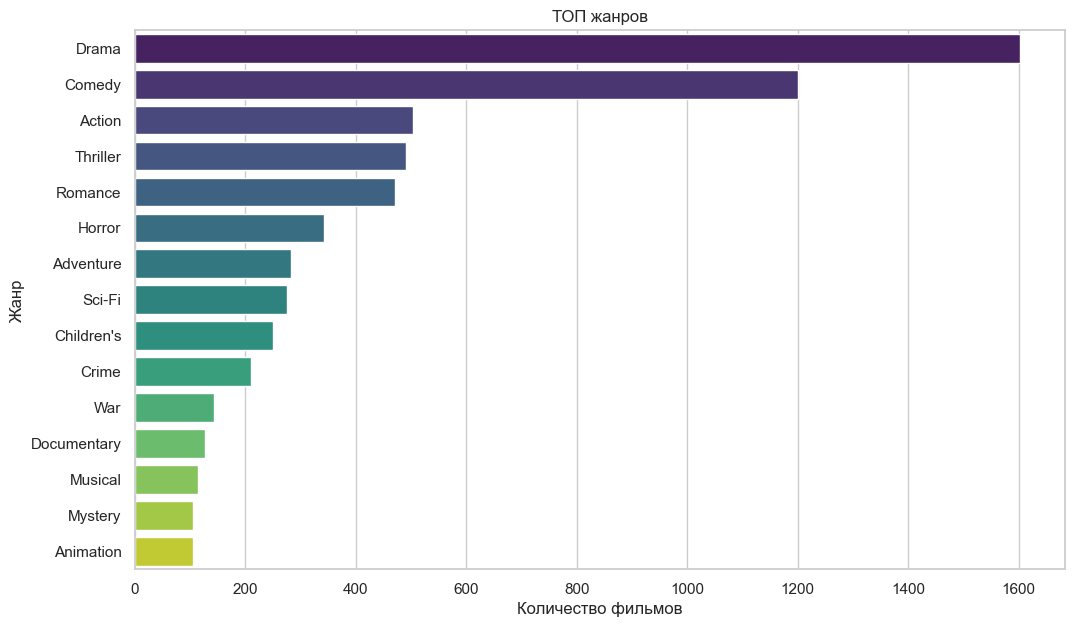

In [13]:
genres_expanded = movies['genres'].str.split('|').explode()
top_genres = genres_expanded.value_counts().head(15)
plt.figure()
sns.barplot(x=top_genres.values, y=top_genres.index, orient='h', palette='viridis')
plt.title("ТОП жанров")
plt.xlabel("Количество фильмов")
plt.ylabel("Жанр")
plt.show()

### Визуализация распределения рейтингов по полу

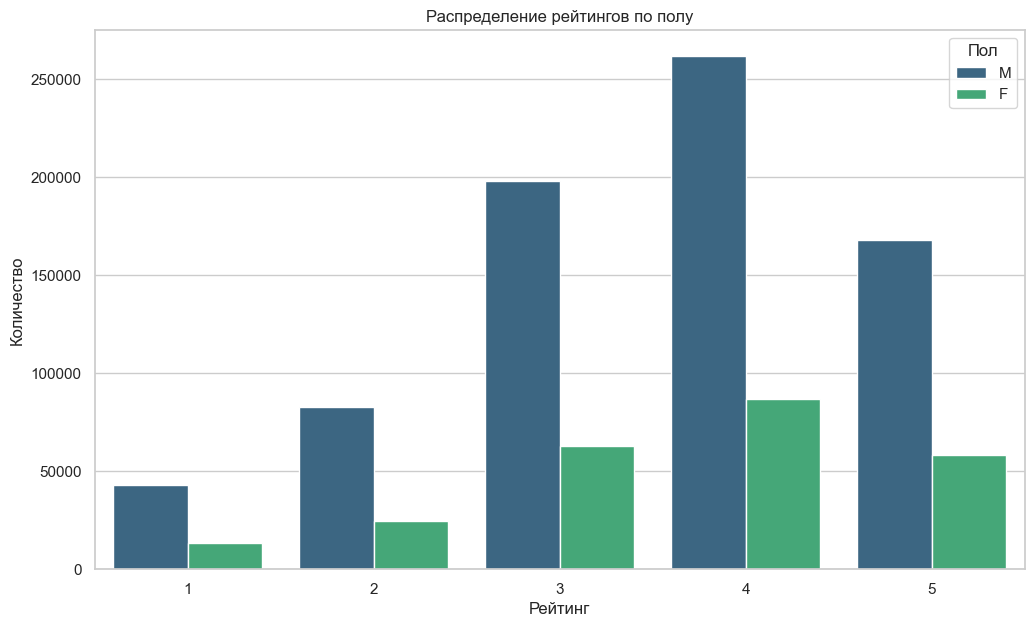

In [14]:
df = ratings.merge(users[['userId','gender']], on='userId')

sns.countplot(data=df, x='rating', hue='gender', palette='viridis')
plt.title('Распределение рейтингов по полу')
plt.xlabel('Рейтинг')
plt.ylabel('Количество')
plt.legend(title='Пол')
plt.show()

## Расчёт взвешенного рейтинга

### Создания функций для расчёта рейтинга
Задача: не давать фильмам с малым количеством голосов (“5 человек поставили 10/10”) обгонять фильмы, у которых много голосов, но чуть меньше средняя оценка.

In [15]:
def weighted_rating_imdb(row, C, m):
        v, R = row['rating_count'], row['rating_mean']
        return ((v / (v + m) * R) + (m / (m + v) * C))

def compute_movie_stats(ratings_df, movies_df):
    stats = ratings_df.groupby('movieId').agg({'rating': ['count', 'mean', 'std']}).round(3)
    stats.columns = ['rating_count', 'rating_mean', 'rating_std']
    stats = stats.reset_index()
    stats = stats.merge(movies_df[['movieId', 'title', 'genres']], on='movieId', how='left')
    C = stats['rating_mean'].mean()
    m = stats['rating_count'].quantile(0.9)

    stats['weighted_rating'] = stats.apply(weighted_rating_imdb, axis=1, args=(C, m))
    stats_sorted = stats.sort_values('weighted_rating', ascending=False)
    return stats_sorted, C, m

In [16]:
movie_stats, _, _ = compute_movie_stats(ratings, movies)

display(movie_stats.head(10))

movies.to_pickle(f"{MODELS_DIR}/movies.pkl")
ratings.to_pickle(f"{MODELS_DIR}/ratings.pkl")
movie_stats.to_pickle(f"{MODELS_DIR}/movie_stats.pkl")

,movieId,rating_count,rating_mean,rating_std,title,genres,weighted_rating
309,318,2227,4.555,0.700,"Shawshank Redemption, The (1994)",Drama,4.230256
253,260,2991,4.454,0.801,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,4.215746
802,858,2223,4.525,0.781,"Godfather, The (1972)",Action|Crime|Drama,4.207229
513,527,2304,4.510,0.764,Schindler's List (1993),Drama|War,4.204321
1108,1198,2514,4.478,0.726,Raiders of the Lost Ark (1981),Action|Adventure,4.199309
49,50,1783,4.517,0.749,"Usual Suspects, The (1995)",Crime|Thriller,4.145902
2557,2762,2459,4.406,0.801,"Sixth Sense, The (1999)",Thriller,4.138975
2651,2858,3428,4.317,0.975,American Beauty (1999),Comedy|Drama,4.127828
579,593,2578,4.352,0.832,"Silence of the Lambs, The (1991)",Drama|Thriller,4.106493
1848,2028,2653,4.337,0.846,Saving Private Ryan (1998),Action|Drama|War,4.100171


## Создание модели для контентой фильтрации
Принцип работы:

- Анализирует характеристики фильмов (название и жанры)
- Находит похожие фильмы на основе схожести контента
- Рекомендует фильмы, похожие на те, что пользователь уже оценил

Процесс обучения:

1. Подготовка данных:
   
   - Очистка названий фильмов (удаление года в скобках)
   - Приведение к нижнему регистру
   - Подготовка жанров
2. Векторизация:
   
   - TF-IDF для названий: использует символьные n-граммы (3-5 символов) для анализа названий
   - TF-IDF для жанров: разделяет жанры по символу "|"
   - Веса: название (60%) + жанры (40%)
3. Вычисление схожести:
   
   - Объединение векторов названий и жанров
   - Расчет косинусного сходства между всеми фильмами
   - Создание матрицы схожести 

Результат: Матрица схожести, где каждый фильм имеет оценку схожести с каждым другим фильмом.

In [17]:

import pickle
import numpy as np
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

w_title = 0.6
w_genre = 0.4

titles_clean = (
    movies['title']
    .str.replace(r"\s*\(\d{4}\)\s*$", "", regex=True)
    .str.lower()
    .fillna("")
)
genres_clean = movies['genres'].fillna("")

tfidf_titles = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=2)
tfidf_genres = TfidfVectorizer(token_pattern=r'[^|]+', lowercase=False)

X_titles = tfidf_titles.fit_transform(titles_clean)
X_genres = tfidf_genres.fit_transform(genres_clean)

X_combined = hstack([w_title * X_titles, w_genre * X_genres])

content_similarity = cosine_similarity(X_combined).astype(np.float32)

movie_to_idx = {mid: i for i, mid in enumerate(movies['movieId'])}
idx_to_movie = {i: mid for mid, i in movie_to_idx.items()}

with open(f"{MODELS_DIR}/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump({"titles": tfidf_titles, "genres": tfidf_genres, "weights": (w_title, w_genre)}, f)
with open(f"{MODELS_DIR}/content_similarity.pkl", "wb") as f:
    pickle.dump(content_similarity, f)
with open(f"{MODELS_DIR}/movie_mappings.pkl", "wb") as f:
    pickle.dump({'movie_to_idx': movie_to_idx, 'idx_to_movie': idx_to_movie}, f)

print("Обновлено: tfidf_vectorizer.pkl, content_similarity.pkl, movie_mappings.pkl")

Обновлено: tfidf_vectorizer.pkl, content_similarity.pkl, movie_mappings.pkl


In [18]:
#  Функция рекомендаций по контенту (название + жанры)

def get_content_based_recommendations(movie_title, n=10):
    matches = movies[movies['title'].str.contains(movie_title, case=False, na=False)]
    if matches.empty:
        return pd.DataFrame()
    movie_id = int(matches.iloc[0]['movieId'])
    if movie_id not in movie_to_idx:
        return pd.DataFrame()
    idx = movie_to_idx[movie_id]

    sims = content_similarity[idx]
    top_idx = np.argsort(sims)[::-1] 

    recs = []
    for j in top_idx:
        if j == idx:
            continue
        mid = idx_to_movie[j]
        movie_row = movies[movies['movieId'] == mid]
        if movie_row.empty:
            continue
        row = movie_row.iloc[0]
        recs.append({
            'movieId': int(mid),
            'title': row['title'],
            'genres': row['genres'],
            'similarity_score': float(sims[j])
        })
        if len(recs) >= n:
            break

    return pd.DataFrame(recs)

# Проба
get_content_based_recommendations("Godfather", 5)

,movieId,title,genres,similarity_score
0,1221,"Godfather: Part II, The (1974)",Action|Crime|Drama,0.765566
1,2023,"Godfather: Part III, The (1990)",Action|Crime|Drama,0.749175
2,2911,"Grandfather, The (El Abuelo) (1998)",Drama,0.453522
3,2912,"Limey, The (1999)",Action|Crime|Drama,0.339284
4,475,In the Name of the Father (1993),Drama,0.336743


## Коллаборативная фильтрация

Принцип работы:

- Анализирует поведение пользователей и их оценки
- Находит скрытые закономерности в предпочтениях
- Предсказывает оценки для непросмотренных фильмов


Процесс обучения:

1. Создание пользовательской матрицы:
   
   ```
   user_movie_matrix: 
   ```
   - Строки = пользователи
   - Столбцы = фильмы
   - Значения = оценки (1-5), пустые ячейки заполнены нулями
2. Обучение NMF (Non-negative Matrix Factorization):
   
   - Цель: Разложить матрицу на два множителя: R ≈ W × H
   - W матрица - профили пользователей 
   - H матрица - профили фильмов 
   - 40 компонентов - скрытые факторы (жанровые предпочтения, настроение и т.д.)
3. Предсказание оценок:
   
   ```
   predicted_ratings = W × H
   ```
   - Восстанавливает полную матрицу оценок
   - Предсказывает оценки для непросмотренных фильмов

In [19]:
user_movie_matrix = ratings.pivot_table(index='userId', columns='movieId', values='rating').fillna(0)
print("user_movie_matrix:", user_movie_matrix.shape)

user_to_idx = {uid: i for i, uid in enumerate(user_movie_matrix.index)}
idx_to_user = {i: uid for uid, i in user_to_idx.items()}

nmf_components = 40 
nmf_model = NMF(n_components=nmf_components, init='random', random_state=42, max_iter=300)
W = nmf_model.fit_transform(user_movie_matrix.values)
H = nmf_model.components_
predicted_ratings = np.dot(W, H) 

print("W:", W.shape, "H:", H.shape, "predicted_ratings:", predicted_ratings.shape)

with open(f"{MODELS_DIR}/collaborative_model.pkl", "wb") as f:
    pickle.dump({'nmf_model': nmf_model, 'W': W, 'H': H}, f)
with open(f"{MODELS_DIR}/user_movie_matrix.pkl", "wb") as f:
    pickle.dump(user_movie_matrix, f)
with open(f"{MODELS_DIR}/user_mappings.pkl", "wb") as f:
    pickle.dump({'user_to_idx': user_to_idx, 'idx_to_user': idx_to_user}, f)

print("Сохранено: collaborative_model.pkl, user_movie_matrix.pkl, user_mappings.pkl")

user_movie_matrix: (6040, 3706)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1759: ConvergenceWarning: Maximum number of iterations 300 reached. Increase it to improve convergence.
  warnings.warn(


W: (6040, 40) H: (40, 3706) predicted_ratings: (6040, 3706)
Сохранено: collaborative_model.pkl, user_movie_matrix.pkl, user_mappings.pkl


Функция get_collaborative_recommendations()
— берёт ID пользователя и возвращает ему список фильмов, которые:

он ещё не смотрел,

но модель считает, что ему понравятся.

Рекомендации делаются с помощью коллаборативной фильтрации —
модель (NMF) смотрит на других пользователей с похожими вкусами
и предсказывает оценки для всех фильмов.

In [20]:
def get_collaborative_recommendations(user_id, n=10):
    if user_id not in user_to_idx:
        return pd.DataFrame()
    u_idx = user_to_idx[user_id]
    user_preds = predicted_ratings[u_idx].copy()

    rated_mask = user_movie_matrix.iloc[u_idx] > 0
    user_preds[rated_mask.values] = 0

    top_movie_indices = np.argsort(user_preds)[-n:][::-1]
    recs = []
    for col_idx in top_movie_indices:
        mid = user_movie_matrix.columns[col_idx]
        movie_row = movies[movies['movieId'] == mid].iloc[0]
        recs.append({
            'movieId': int(mid),
            'title': movie_row['title'],
            'genres': movie_row['genres'],
            'predicted_rating': float(user_preds[col_idx]) * 2
        })
    return pd.DataFrame(recs)


test_user_id = int(ratings['userId'].iloc[0])
display(get_collaborative_recommendations(test_user_id, 5))

,movieId,title,genres,predicted_rating
0,364,"Lion King, The (1994)",Animation|Children's|Musical,5.831106
1,34,Babe (1995),Children's|Comedy|Drama,5.428579
2,318,"Shawshank Redemption, The (1994)",Drama,5.141395
3,593,"Silence of the Lambs, The (1991)",Drama|Thriller,4.499327
4,2081,"Little Mermaid, The (1989)",Animation|Children's|Comedy|Musical|Romance,4.278716


## Лучшие по жанрам

Статистика фильмов:

- Подсчет количества оценок для каждого фильма
- Вычисление средней оценки и стандартного отклонения
- Расчет взвешенного рейтинга (учитывает популярность)
Рекомендации по жанрам:

- Фильтрация фильмов по жанрам
- Сортировка по взвешенному рейтингу

In [21]:
def get_top_popular_movies(n=10):
    return movie_stats.head(n)

def get_recommendations_by_genre(genre, n=10):
    genre_mask = movie_stats['genres'].str.contains(genre, case=False, na=False)
    return movie_stats[genre_mask].head(n)

display(get_recommendations_by_genre("Animation", 5))

,movieId,rating_count,rating_mean,rating_std,title,genres,weighted_rating
1066,1148,882,4.508,0.709,"Wrong Trousers, The (1993)",Animation|Comedy,3.933493
0,1,2077,4.147,0.852,Toy Story (1995),Animation|Children's|Comedy,3.910952
2898,3114,1585,4.219,0.893,Toy Story 2 (1999),Animation|Children's|Comedy,3.910081
708,745,657,4.521,0.667,"Close Shave, A (1995)",Animation|Comedy|Thriller,3.846423
689,720,438,4.427,0.805,Wallace & Gromit: The Best of Aardman Animatio...,Animation,3.684620


## Итоговое сохранение

In [22]:
def save_all_models(models_dir=MODELS_DIR):
    # базовые
    movies.to_pickle(f'{models_dir}/movies.pkl')
    ratings.to_pickle(f'{models_dir}/ratings.pkl')
    movie_stats.to_pickle(f'{models_dir}/movie_stats.pkl')

    # контентные
    with open(f'{models_dir}/tfidf_vectorizer.pkl', 'wb') as f:
        pickle.dump({"titles": tfidf_titles, "genres": tfidf_genres, "weights": (w_title, w_genre)}, f)
    with open(f'{models_dir}/content_similarity.pkl', 'wb') as f:
        pickle.dump(content_similarity, f)
    with open(f'{models_dir}/movie_mappings.pkl', 'wb') as f:
        pickle.dump({'movie_to_idx': movie_to_idx, 'idx_to_movie': idx_to_movie}, f)

    # коллаборативные
    with open(f'{models_dir}/user_movie_matrix.pkl', 'wb') as f:
        pickle.dump(user_movie_matrix, f)
    with open(f'{models_dir}/user_mappings.pkl', 'wb') as f:
        pickle.dump({'user_to_idx': user_to_idx, 'idx_to_user': idx_to_user}, f)

    print(f"Артефакты сохранены в {models_dir}")
    print("\nРазмеры сохраненных файлов:")
    for fname in os.listdir(models_dir):
        fp = os.path.join(models_dir, fname)
        if os.path.isfile(fp):
            print(f"- {fname}: {os.path.getsize(fp)/(1024*1024):.2f} MB")
            
save_all_models()

Артефакты сохранены в models

Размеры сохраненных файлов:
- tfidf_vectorizer.pkl: 0.26 MB
- movies.pkl: 0.16 MB
- movie_stats.pkl: 0.29 MB
- collaborative_model.pkl: 2.97 MB
- ratings.pkl: 30.52 MB
- user_movie_matrix.pkl: 170.85 MB
- content_similarity.pkl: 57.52 MB
- user_mappings.pkl: 0.07 MB
- movie_mappings.pkl: 0.04 MB


### Итог

- Загрузили датасеты MovieLens 1M и провели первичный анализ:
  `users=6040`, `movies=3883`, `ratings=1,000,209`; пропусков не обнаружено.
- Построили матрицу `user_movie_matrix` (пользователь × фильм) из оценок.
- Контентная модель: векторизация названий TF‑IDF и косинусное сходство для поиска похожих фильмов.
- Коллаборативная модель: обучили NMF (`n_components=40`), получили латентные факторы `W` и `H`,
  восстановили `predicted_ratings = W @ H` для предсказания недостающих оценок.
- Сохранили артефакты для последующего использования:
  `models/collaborative_model.pkl`, `models/user_movie_matrix.pkl`, `models/user_mappings.pkl`.
- Модели готовы к интеграции в API/GUI для выдачи рекомендаций (топ‑N по пользователю и похожие фильмы по контенту).